In [93]:
import pandas as pd
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
import numpy as np

import matplotlib.pyplot as plt

In [94]:
# 1. Load the data
df = pd.read_csv('/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/indices_region.csv', encoding='utf-8')

In [95]:
# 2. Clean and Filter
# Exclude Galapagos (NaNs) and the chaotic year 2000
df = df[df['region'] != 'Galápagos']
df = df[df['ano'] >= 2001] 

In [96]:
df['region'].value_counts()

region
Amazonía                96
Azuay                   96
Costa, Santo Domingo    96
El Oro                  96
Guayas                  96
Los Ríos                96
Manabí                  96
Pichincha               96
Sierra                  96
Name: count, dtype: int64

In [97]:
# Create a 'Date' index for the Panel
df['date'] = pd.to_datetime(df['ano'].astype(str) + 'Q' + df['trimestre'].astype(str))
df = df.set_index(['region', 'date'])

/tmp/ipykernel_103128/3453128801.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['ano'].astype(str) + 'Q' + df['trimestre'].astype(str))


# Naive models

In [31]:
# 3. Define the Model (Two-Way Fixed Effects)
# EntityEffects = Region Fixed Effects
# TimeEffects = Time Fixed Effects
mod = PanelOLS.from_formula('fgt0 ~ kaitz_indice + EntityEffects + TimeEffects', data=df)

# 4. Run the Regression
# clustered_entity=True handles the correlation of errors within regions (Standard Practice)
res = mod.fit(cov_type='clustered', cluster_entity=True)

print(res)

                          PanelOLS Estimation Summary                           
Dep. Variable:                   fgt0   R-squared:                        0.3148
Estimator:                   PanelOLS   R-squared (Between):              0.7794
No. Observations:                 846   R-squared (Within):              -0.0560
Date:                Fri, Feb 27 2026   R-squared (Overall):              0.6505
Time:                        20:22:16   Log-likelihood                    1416.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      341.32
Entities:                           9   P-value                           0.0000
Avg Obs:                       94.000   Distribution:                   F(1,743)
Min Obs:                       94.000                                           
Max Obs:                       94.000   F-statistic (robust):             33.256
                            

## Robustness

In [ ]:
# Create necessary variables for the checks
df['kaitz_sq'] = df['kaitz_indice'] ** 2
df['log_salario'] = np.log(df['salario_minimo'])
df['log_mediana'] = np.log(df['ingreso_mediana'])
df['const'] = 1  # Constant term is often required/good practice

In [ ]:
# ==============================================================================
# CHECK 1: The Inequality Trade-off (Dependent Variable: a50)
# ==============================================================================
print("\n" + "="*80)
print("CHECK 1: INEQUALITY TRADE-OFF (Dependent Variable: a50)")
print("Hypothesis: Does Min Wage reduce inequality even if it increases poverty?")
print("="*80)

mod_ineq = PanelOLS(df['a50'], df[['const', 'kaitz_indice']], entity_effects=True, time_effects=True)
res_ineq = mod_ineq.fit(cov_type='clustered', cluster_entity=True)
print(res_ineq)


CHECK 1: INEQUALITY TRADE-OFF (Dependent Variable: a50)
Hypothesis: Does Min Wage reduce inequality even if it increases poverty?
                          PanelOLS Estimation Summary                           
Dep. Variable:                    a50   R-squared:                        0.0481
Estimator:                   PanelOLS   R-squared (Between):              0.1351
No. Observations:                 877   R-squared (Within):              -0.0230
Date:                Mon, Feb 23 2026   R-squared (Overall):             -0.0163
Time:                        15:19:58   Log-likelihood                    1805.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      38.892
Entities:                          13   P-value                           0.0000
Avg Obs:                       67.462   Distribution:                   F(1,770)
Min Obs:                       4.0000                      

/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [ ]:
# ==============================================================================
# CHECK 2: Non-Linearity (The "U" Shape)
# ==============================================================================
print("\n" + "="*80)
print("CHECK 2: NON-LINEARITY (Testing for 'Optimal' Level)")
print("Hypothesis: Is the relationship U-shaped? (Good at low levels, bad at high?)")
print("="*80)

mod_sq = PanelOLS(df['fgt0'], df[['const', 'kaitz_indice', 'kaitz_sq']], entity_effects=True, time_effects=True)
res_sq = mod_sq.fit(cov_type='clustered', cluster_entity=True)
print(res_sq)


CHECK 2: NON-LINEARITY (Testing for 'Optimal' Level)
Hypothesis: Is the relationship U-shaped? (Good at low levels, bad at high?)
                          PanelOLS Estimation Summary                           
Dep. Variable:                   fgt0   R-squared:                        0.5452
Estimator:                   PanelOLS   R-squared (Between):              0.6385
No. Observations:                 877   R-squared (Within):              -0.2951
Date:                Mon, Feb 23 2026   R-squared (Overall):              0.0483
Time:                        15:21:03   Log-likelihood                    1648.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      460.99
Entities:                          13   P-value                           0.0000
Avg Obs:                       67.462   Distribution:                   F(2,769)
Min Obs:                       4.0000                      

/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [ ]:
# ==============================================================================
# CHECK 3 (CORRECTED): The Denominator Effect
# ==============================================================================

# PATH A: The Rigorous "Denominator" Test
# We keep TimeEffects to control for national shocks, but we only look at local income.
print("\n" + "="*80)
print("CHECK 3A: The Denominator Test (Local Income Shocks)")
print("Hypothesis: Does a drop in local median income significantly increase poverty?")
print("If YES -> The 'Perverse' Kaitz result is likely due to income shocks (Denominator Effect).")
print("="*80)

# Note: We removed 'log_salario' and 'const' to avoid absorption
mod_denom = PanelOLS(df['fgt0'], df[['log_mediana']], entity_effects=True, time_effects=True)
res_denom = mod_denom.fit(cov_type='clustered', cluster_entity=True)
print(res_denom)


# PATH B: The "Naive" Decomposition
# We DROP TimeEffects so we can see the Minimum Wage coefficient.
print("\n" + "="*80)
print("CHECK 3B: Naive Decomposition (No Time Fixed Effects)")
print("Hypothesis: What is the raw correlation of Min Wage vs Poverty?")
print("Warning: This does not control for other national trends (like oil prices).")
print("="*80)

# We include 'const' here because we don't have TimeEffects to act as intercepts
mod_naive = PanelOLS(df['fgt0'], df[['const', 'log_salario', 'log_mediana']], entity_effects=True, time_effects=False)
res_naive = mod_naive.fit(cov_type='clustered', cluster_entity=True)
print(res_naive)


CHECK 3A: The Denominator Test (Local Income Shocks)
Hypothesis: Does a drop in local median income significantly increase poverty?
If YES -> The 'Perverse' Kaitz result is likely due to income shocks (Denominator Effect).
                          PanelOLS Estimation Summary                           
Dep. Variable:                   fgt0   R-squared:                        0.5309
Estimator:                   PanelOLS   R-squared (Between):             -18.696
No. Observations:                 877   R-squared (Within):               0.8554
Date:                Mon, Feb 23 2026   R-squared (Overall):             -17.161
Time:                        15:23:13   Log-likelihood                    1634.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      871.32
Entities:                          13   P-value                           0.0000
Avg Obs:                       67.462   Distrib

/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


## Lagged model

In [ ]:
# ==============================================================================
# FINAL CHECK: THE LAGGED MODEL (Dynamic Effects)
# ==============================================================================

# 1. Create Lagged Variables
# We group by region to ensure we don't shift data from one province to another
df['kaitz_lag1'] = df.groupby('region')['kaitz_indice'].shift(1) # 3 Months
df['kaitz_lag2'] = df.groupby('region')['kaitz_indice'].shift(2) # 6 Months
df['kaitz_lag4'] = df.groupby('region')['kaitz_indice'].shift(4) # 1 Year

df['log_salario_lag2'] = df.groupby('region')['log_salario'].shift(2) # Wage 6 months ago
df['log_mediana_lag2'] = df.groupby('region')['log_mediana'].shift(2) # Income 6 months ago

# Drop NaN values created by shifting (we lose the first year of data)
df_lagged = df.dropna(subset=['kaitz_lag4', 'log_salario_lag2']).copy()

print("\n" + "="*80)
print("MODEL 1: Distributed Lag Model (Kaitz Index)")
print("Hypothesis: Does the 'bite' reduce poverty after a delay (3, 6, or 12 months)?")
print("Look for NEGATIVE coefficients on the lags.")
print("="*80)

# We include Current + Lags to see the full timeline
mod_dynamic = PanelOLS(df_lagged['fgt0'], 
                       df_lagged[['const', 'kaitz_indice', 'kaitz_lag1', 'kaitz_lag2', 'kaitz_lag4']], 
                       entity_effects=True, time_effects=True)
res_dynamic = mod_dynamic.fit(cov_type='clustered', cluster_entity=True)
print(res_dynamic)


print("\n" + "="*80)
print("MODEL 2: The 6-Month Wage Test (Decomposed)")
print("Hypothesis: Does a raw Minimum Wage hike today reduce poverty 6 months later?")
print("Look at 'log_salario_lag2'.")
print("="*80)

# No TimeEffects here to avoid absorption of the national wage
mod_wage_lag = PanelOLS(df_lagged['fgt0'], 
                        df_lagged[['const', 'log_salario_lag2', 'log_mediana_lag2']], 
                        entity_effects=True, time_effects=False)
res_wage_lag = mod_wage_lag.fit(cov_type='clustered', cluster_entity=True)
print(res_wage_lag)


MODEL 1: Distributed Lag Model (Kaitz Index)
Hypothesis: Does the 'bite' reduce poverty after a delay (3, 6, or 12 months)?
Look for NEGATIVE coefficients on the lags.
                          PanelOLS Estimation Summary                           
Dep. Variable:                   fgt0   R-squared:                        0.4112
Estimator:                   PanelOLS   R-squared (Between):              0.7466
No. Observations:                 777   R-squared (Within):              -0.8057
Date:                Mon, Feb 23 2026   R-squared (Overall):             -0.0805
Time:                        15:30:49   Log-likelihood                    1394.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      118.37
Entities:                          10   P-value                           0.0000
Avg Obs:                       77.700   Distribution:                   F(4,678)
Min Obs:             

/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


Testing the trend

In [ ]:
# ==============================================================================
# THE FINAL STRESS TEST: Controlling for the Time Trend
# ==============================================================================

# 1. Create a Linear Time Trend variable
# We assign a number to each date (0, 1, 2, 3...)
dates = df_lagged.index.get_level_values('date').unique().sort_values()
date_map = {date: i for i, date in enumerate(dates)}
df_lagged['time_trend'] = df_lagged.index.get_level_values('date').map(date_map)

print("\n" + "="*80)
print("STRESS TEST: Model 2 with Linear Time Trend")
print("Hypothesis: Does the wage effect survive when we control for the general passage of time?")
print("Look at 'log_salario_lag2'.")
print("="*80)

# We add 'time_trend' to the model
mod_trend = PanelOLS(df_lagged['fgt0'], 
                     df_lagged[['const', 'log_salario_lag2', 'log_mediana_lag2', 'time_trend']], 
                     entity_effects=True, time_effects=False)
res_trend = mod_trend.fit(cov_type='clustered', cluster_entity=True)
print(res_trend)


STRESS TEST: Model 2 with Linear Time Trend
Hypothesis: Does the wage effect survive when we control for the general passage of time?
Look at 'log_salario_lag2'.
                          PanelOLS Estimation Summary                           
Dep. Variable:                   fgt0   R-squared:                        0.5529
Estimator:                   PanelOLS   R-squared (Between):              0.6482
No. Observations:                 780   R-squared (Within):               0.5529
Date:                Mon, Feb 23 2026   R-squared (Overall):              0.5399
Time:                        15:35:15   Log-likelihood                    983.14
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      316.21
Entities:                          10   P-value                           0.0000
Avg Obs:                       78.000   Distribution:                   F(3,767)
Min Obs:                   

/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


# Sotomayor

## Evento = every rise

In [98]:
# Parameters
WINDOW_PRE = 4
WINDOW_POST = 4
OUTCOMES = ['fgt0', 'fgt1', 'fgt2', 'a25', 'a50', 'a75']

In [99]:
df = df.reset_index()

In [100]:
time_vals = df[['ano', 'trimestre']].drop_duplicates().sort_values(['ano', 'trimestre']).reset_index(drop=True)
time_vals['time'] = time_vals.index + 1
time_vals

df = df.merge(time_vals, on=['ano', 'trimestre']).sort_values(['region', 'time']).reset_index(drop=True)

In [101]:
# Let's define the event of incresing salario mínimo
sm = df[['time', 'salario_minimo']].drop_duplicates().sort_values('time')
sm['delta_sm'] = sm['salario_minimo'].diff()
eventos = sm[sm['delta_sm'] > 0]['time'].values
eventos

array([ 5,  9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57, 61, 65, 69,
       73, 85, 89, 93])

In [102]:
# Construir stacked dataset
chunks = []
for e_idx, t0 in enumerate(eventos):
    chunk = df[(df['time'] >= t0 - WINDOW_PRE) & (df['time'] <= t0 + WINDOW_POST)].copy()

    kaitz_pre = (df[df['time'] == t0 - 1][['region', 'kaitz_indice']]
                 .rename(columns={'kaitz_indice': 'kaitz_pre'}))
    
    if kaitz_pre.empty:
        continue

    chunk = chunk.merge(kaitz_pre, on='region', how='left')
    chunk['tratamiento'] = (chunk['kaitz_pre'] > kaitz_pre['kaitz_pre'].median()).astype(int)
    chunk['event_time'] = chunk['time'] - t0
    chunk['event_id'] = e_idx
    chunks.append(chunk)

stacked = pd.concat(chunks, ignore_index=True)
stacked['unit_id'] = stacked['region'] + '_e' + stacked['event_id'].astype(str)

In [103]:
stacked.to_csv('/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/modelos/datos_modelos/stacked_evento_pre_mayor_mediana.csv')

In [104]:
# Dummies de interacción para cada evento si la región es tratamiento
k_values = sorted([k for k in stacked['event_time'].unique() if k != 0])
for k in k_values:
    stacked[f'D_k{k}'] = (
        (stacked['event_time'] == k) &
        (stacked['tratamiento'] == 1) 
    ).astype(float)

interaccion = [f'D_k{k}' for k in k_values]

In [105]:
interaccion

['D_k-4', 'D_k-3', 'D_k-2', 'D_k-1', 'D_k1', 'D_k2', 'D_k3', 'D_k4']

In [106]:
# Rename columns for error while reading '-'
rename_map = {f'D_k{k}': f'D_km{abs(k)}' if k < 0 else f'D_k{k}' for k in k_values}
stacked = stacked.rename(columns=rename_map)
interaccion = list(rename_map.values())

In [111]:
results = {}
for outcome in OUTCOMES:
    panel   = stacked.set_index(['unit_id', 'time'])
    formula = f'{outcome} ~ ' + ' + '.join(interaccion) + ' + EntityEffects + TimeEffects'
    res     = PanelOLS.from_formula(formula, data=panel, drop_absorbed=True).fit(
        cov_type='clustered', cluster_entity=True
    )

    coef_df = pd.DataFrame({
        'k':    k_values,
        'coef': [res.params.get(var, np.nan) for var in interaccion],
        'se':   [res.std_errors.get(var, np.nan) for var in interaccion],
        'pval': [res.pvalues.get(var, np.nan) for var in interaccion],
    })
    coef_df['ci_low']  = coef_df['coef'] - 1.96 * coef_df['se']
    coef_df['ci_high'] = coef_df['coef'] + 1.96 * coef_df['se']

    ref = pd.DataFrame({'k':[0],'coef':[0.],'se':[0.],'pval':[np.nan],'ci_low':[0.],'ci_high':[0.]})
    coef_df = pd.concat([coef_df, ref]).sort_values('k').reset_index(drop=True)

    results[outcome] = coef_df   # <-- clave correcta

/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/p

In [113]:
results

{'fgt0':    k      coef        se      pval    ci_low   ci_high
 0 -4  0.006931  0.009323  0.457334 -0.011341  0.025203
 1 -3  0.022803  0.009826  0.020443  0.003545  0.042061
 2 -2  0.009492  0.009689  0.327411 -0.009498  0.028482
 3 -1  0.046588  0.009992  0.000003  0.027003  0.066172
 4  0  0.000000  0.000000       NaN  0.000000  0.000000
 5  1  0.018065  0.008354  0.030742  0.001692  0.034438
 6  2  0.007341  0.008824  0.405603 -0.009954  0.024635
 7  3  0.038631  0.009801  0.000085  0.019422  0.057840
 8  4 -0.004921  0.009495  0.604338 -0.023531  0.013689,
 'fgt1':    k      coef        se      pval    ci_low   ci_high
 0 -4  0.010141  0.006203  0.102302 -0.002017  0.022300
 1 -3  0.012588  0.006343  0.047383  0.000156  0.025019
 2 -2  0.007513  0.006297  0.233022 -0.004829  0.019856
 3 -1  0.027207  0.006377  0.000021  0.014707  0.039707
 4  0  0.000000  0.000000       NaN  0.000000  0.000000
 5  1  0.005866  0.004831  0.224876 -0.003603  0.015336
 6  2 -0.000613  0.004853  0.89

### Gráficos

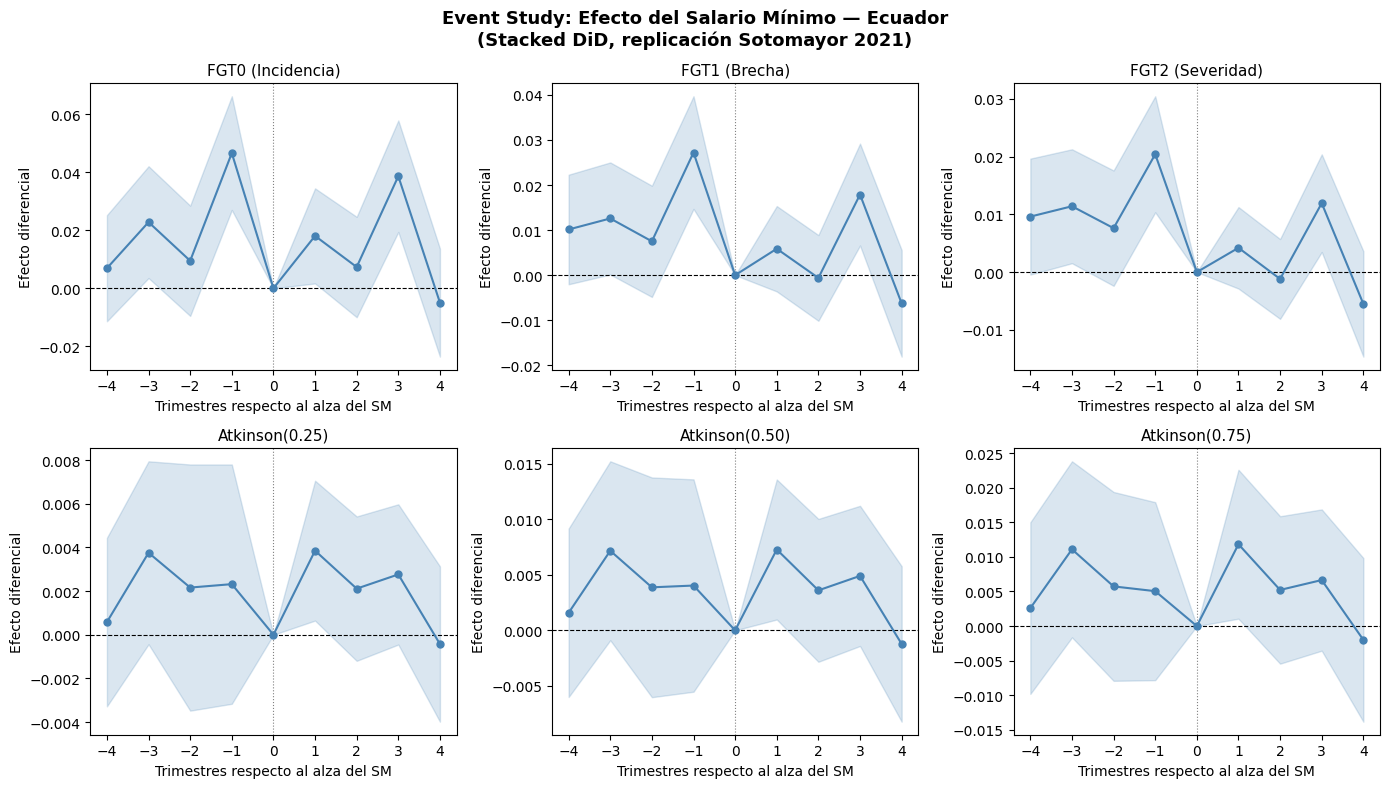

In [114]:
labels = {
    'fgt0':'FGT0 (Incidencia)', 'fgt1':'FGT1 (Brecha)', 'fgt2':'FGT2 (Severidad)',
    'a25':'Atkinson(0.25)',     'a50':'Atkinson(0.50)', 'a75':'Atkinson(0.75)'
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, outcome in zip(axes.flatten(), OUTCOMES):
    cd = results[outcome]
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axvline(0, color='gray',  lw=0.8, ls=':')
    ax.fill_between(cd['k'], cd['ci_low'], cd['ci_high'], alpha=0.2, color='steelblue')
    ax.plot(cd['k'], cd['coef'], 'o-', color='steelblue', lw=1.5, ms=5)
    ax.set_title(labels[outcome], fontsize=11)
    ax.set_xlabel('Trimestres respecto al alza del SM')
    ax.set_ylabel('Efecto diferencial')
    ax.set_xticks(range(-WINDOW_PRE, WINDOW_POST + 1))

plt.suptitle('Event Study: Efecto del Salario Mínimo — Ecuador\n(Stacked DiD, replicación Sotomayor 2021)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('event_study_ecuador.png', dpi=150, bbox_inches='tight')
plt.show()

## Evento = high increases

In [115]:
WINDOW_PRE  = 4
WINDOW_POST = 4
OUTCOMES    = ['fgt0', 'fgt1', 'fgt2', 'a25', 'a50', 'a75']
UMBRAL_ALZA = 0.75   # percentil para "alzas grandes" (cambia a 0.5 para mediana)

In [116]:
sm = df[['time','salario_minimo']].drop_duplicates().sort_values('time')
sm['delta_sm'] = sm['salario_minimo'].diff()

umbral = sm['delta_sm'].quantile(UMBRAL_ALZA)
events = sm[sm['delta_sm'] >= umbral]['time'].values

print(f"Umbral ΔSM (p{int(UMBRAL_ALZA*100)}): {umbral:.2f}")
print(f"Eventos seleccionados: {len(events)}")
print(sm[sm['delta_sm'] >= umbral][['time','salario_minimo','delta_sm']])

Umbral ΔSM (p75): 0.00
Eventos seleccionados: 92
    time  salario_minimo  delta_sm
1      2           85.65      0.00
2      3           85.65      0.00
3      4           85.65      0.00
4      5          104.88     19.23
5      6          104.88      0.00
..   ...             ...       ...
91    92          450.00      0.00
92    93          460.00     10.00
93    94          460.00      0.00
94    95          460.00      0.00
95    96          460.00      0.00

[92 rows x 3 columns]


In [117]:
chunks = []
for e_idx, t0 in enumerate(events):
    chunk = df[(df['time'] >= t0 - WINDOW_PRE) & (df['time'] <= t0 + WINDOW_POST)].copy()

    kaitz_pre = (df[df['time'] == t0 - 1][['region','kaitz_indice']]
                   .rename(columns={'kaitz_indice': 'kaitz_pre'}))
    if kaitz_pre.empty:
        continue

    chunk = chunk.merge(kaitz_pre, on='region', how='left')
    chunk['treated']    = (chunk['kaitz_pre'] > kaitz_pre['kaitz_pre'].median()).astype(int)
    chunk['event_time'] = chunk['time'] - t0
    chunk['event_id']   = e_idx
    chunks.append(chunk)

stacked = pd.concat(chunks, ignore_index=True)
stacked['unit_id'] = stacked['region'] + '_e' + stacked['event_id'].astype(str)

In [119]:
stacked.to_csv('/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/modelos/datos_modelos/stacked_evento_pre_alza_grande.csv')

In [120]:
k_values = sorted([k for k in stacked['event_time'].unique() if k != 0])
rename_map = {f'D_k{k}': f'D_km{abs(k)}' if k < 0 else f'D_k{k}' for k in k_values}

for k in k_values:
    col = rename_map[f'D_k{k}']
    stacked[col] = ((stacked['event_time'] == k) & (stacked['treated'] == 1)).astype(float)

interaction_vars = list(rename_map.values())

In [121]:
results_large = {}
for outcome in OUTCOMES:
    panel   = stacked.set_index(['unit_id', 'time'])
    formula = f'{outcome} ~ ' + ' + '.join(interaction_vars) + ' + EntityEffects + TimeEffects'
    res     = PanelOLS.from_formula(formula, data=panel, drop_absorbed=True).fit(
                  cov_type='clustered', cluster_entity=True)

    coef_df = pd.DataFrame({
        'k':    k_values,
        'coef': [res.params.get(var, np.nan) for var in interaction_vars],
        'se':   [res.std_errors.get(var, np.nan) for var in interaction_vars],
        'pval': [res.pvalues.get(var, np.nan) for var in interaction_vars],
    })
    coef_df['ci_low']  = coef_df['coef'] - 1.96 * coef_df['se']
    coef_df['ci_high'] = coef_df['coef'] + 1.96 * coef_df['se']
    ref = pd.DataFrame({'k':[0],'coef':[0.],'se':[0.],'pval':[np.nan],'ci_low':[0.],'ci_high':[0.]})
    results_large[outcome] = pd.concat([coef_df, ref]).sort_values('k').reset_index(drop=True)

/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)
/home/edu/Dropbox/Edu/repositorios/salario-minimo-y-pobreza-Ecuador/.venv/lib/p

## Gráficos

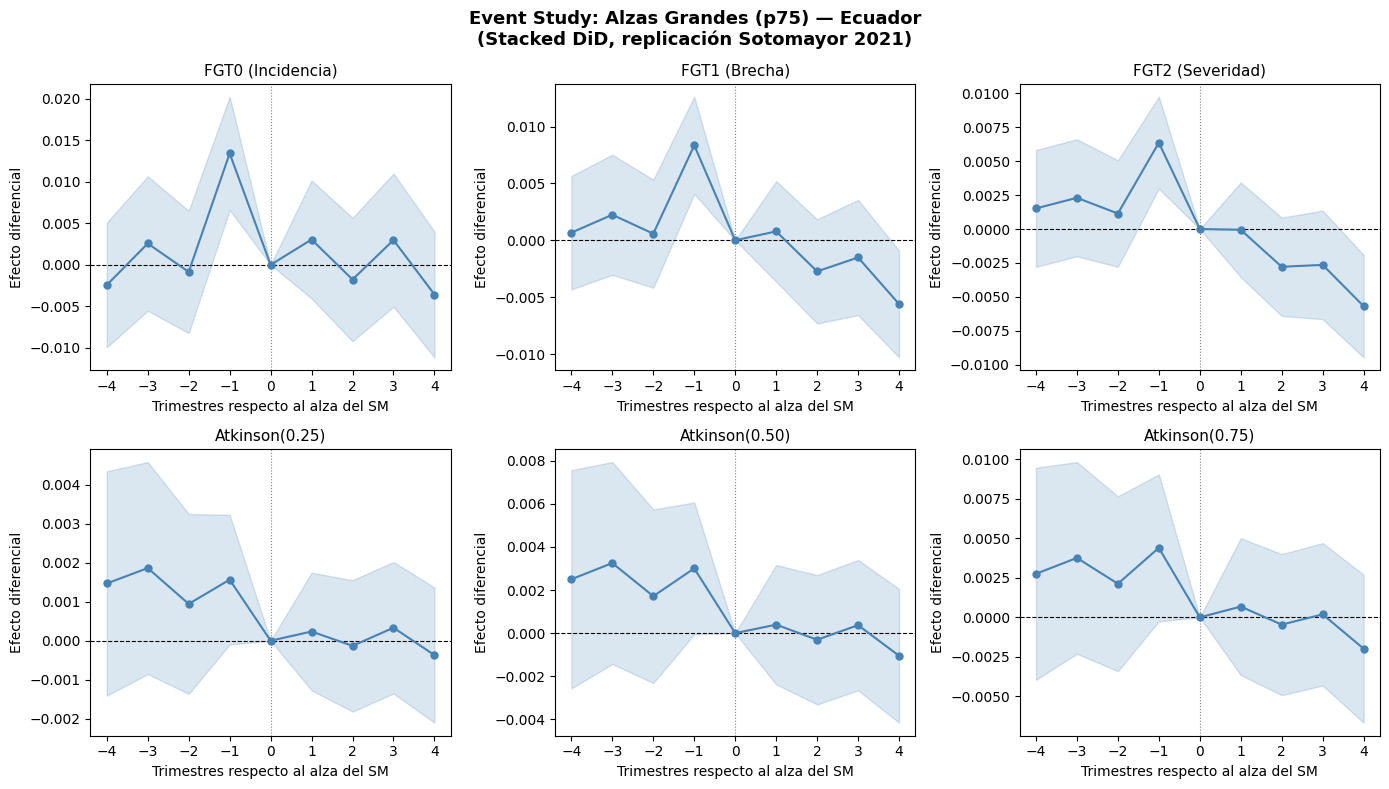

In [122]:
labels = {
    'fgt0':'FGT0 (Incidencia)', 'fgt1':'FGT1 (Brecha)', 'fgt2':'FGT2 (Severidad)',
    'a25':'Atkinson(0.25)',     'a50':'Atkinson(0.50)', 'a75':'Atkinson(0.75)'
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, outcome in zip(axes.flatten(), OUTCOMES):
    cd = results_large[outcome]
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axvline(0, color='gray',  lw=0.8, ls=':')
    ax.fill_between(cd['k'], cd['ci_low'], cd['ci_high'], alpha=0.2, color='steelblue')
    ax.plot(cd['k'], cd['coef'], 'o-', color='steelblue', lw=1.5, ms=5)
    ax.set_title(labels[outcome], fontsize=11)
    ax.set_xlabel('Trimestres respecto al alza del SM')
    ax.set_ylabel('Efecto diferencial')
    ax.set_xticks(range(-WINDOW_PRE, WINDOW_POST + 1))

plt.suptitle(f'Event Study: Alzas Grandes (p{int(UMBRAL_ALZA*100)}) — Ecuador\n(Stacked DiD, replicación Sotomayor 2021)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('event_study_large_shocks.png', dpi=150, bbox_inches='tight')
plt.show()